In [5]:
# ============================================================
# EEP Annex A — GHG Emissions by TES Sector (1990–2050)
# Data source: DESNZ EEP 2024-2050, Annex A (published Feb 2026)
# ============================================================

In [14]:
# ── Cell 1: 导入库 & 路径设置 ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

ANNEX_PATH = "C:/Users/888/Desktop/UCL Moduels/AFinal_BENV0096 Dissertation Energy Systems and Data Analytics/Data_raw/UK Emission/Annex_A_GHG_by_TES_sector.ods" 

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

YEARS      = list(range(1990, 2051))
YEAR_COLS  = list(range(4, 65))       # col 4–64 对应 1990–2050
SCENARIOS  = ["Reference", "FFP_Low", "FFP_High", "GDP_Low", "GDP_High", "Existing"]

SECTORS = [
    "Agriculture", "Buildings and product uses", "Domestic Transport",
    "Electricity supply", "Fuel supply", "Industry", "LULUCF", "Waste",
]
SECTOR_ROWS = {"Agriculture": 8,
    "Buildings and product uses": 9,
    "Domestic Transport": 10,
    "Electricity supply": 11,
    "Fuel supply": 12,
    "IAS": 13,
    "Industry": 14,
    "LULUCF": 15,
    "Waste": 16,}  

SECTOR_COLORS = {
    "Electricity supply":        "#e74c3c",
    "Domestic Transport":        "#3498db",
    "Buildings and product uses":"#f39c12",
    "Industry":                  "#2ecc71",
    "Agriculture":               "#9b59b6",
    "Fuel supply":               "#1abc9c",
    "Waste":                     "#e67e22",
    "LULUCF":                    "#95a5a6",
}

SECTOR_SHORT = {
    "Agriculture":               "Agriculture",
    "Buildings and product uses":"Buildings",
    "Domestic Transport":        "Transport",
    "Electricity supply":        "Electricity",
    "Fuel supply":               "Fuel supply",
    "Industry":                  "Industry",
    "LULUCF":                    "LULUCF",
    "Waste":                     "Waste",
}


In [15]:
# ── Cell 2: 数据读取函数 ──────────────────────────────────
def load_sheet(scenario):
    """读取指定情景sheet，返回 DataFrame(index=year/cb, columns=coverage)"""
    df_raw = pd.read_excel(ANNEX_PATH, sheet_name=scenario,
                           header=None, engine="odf")
    # 年度数据 1990-2050
    data = {}
    for name, r in SECTOR_ROWS.items():
        data[name] = df_raw.iloc[r, YEAR_COLS].astype(float).values
    data["Total (exc. IAS)"] = df_raw.iloc[3, YEAR_COLS].astype(float).values
    data["Total (inc. IAS)"] = df_raw.iloc[4, YEAR_COLS].astype(float).values
    return pd.DataFrame(data, index=YEARS)

# 读取所有情景
sheets = {sc: load_sheet(sc) for sc in SCENARIOS}
ref = sheets["Reference"]

print("✅ All scenarios loaded")
print(f"   Reference 2023 total (exc. IAS): {ref.loc[2023, 'Total (exc. IAS)']:.1f} MtCO₂e")
print(f"   Reference 2050 total (exc. IAS): {ref.loc[2050, 'Total (exc. IAS)']:.1f} MtCO₂e")
print(f"   Reference 2050 Transport:        {ref.loc[2050, 'Domestic Transport']:.1f} MtCO₂e")
print(f"   Reference 2050 Buildings:        {ref.loc[2050, 'Buildings and product uses']:.1f} MtCO₂e")

✅ All scenarios loaded
   Reference 2023 total (exc. IAS): 385.0 MtCO₂e
   Reference 2050 total (exc. IAS): 290.2 MtCO₂e
   Reference 2050 Transport:        49.9 MtCO₂e
   Reference 2050 Buildings:        84.6 MtCO₂e


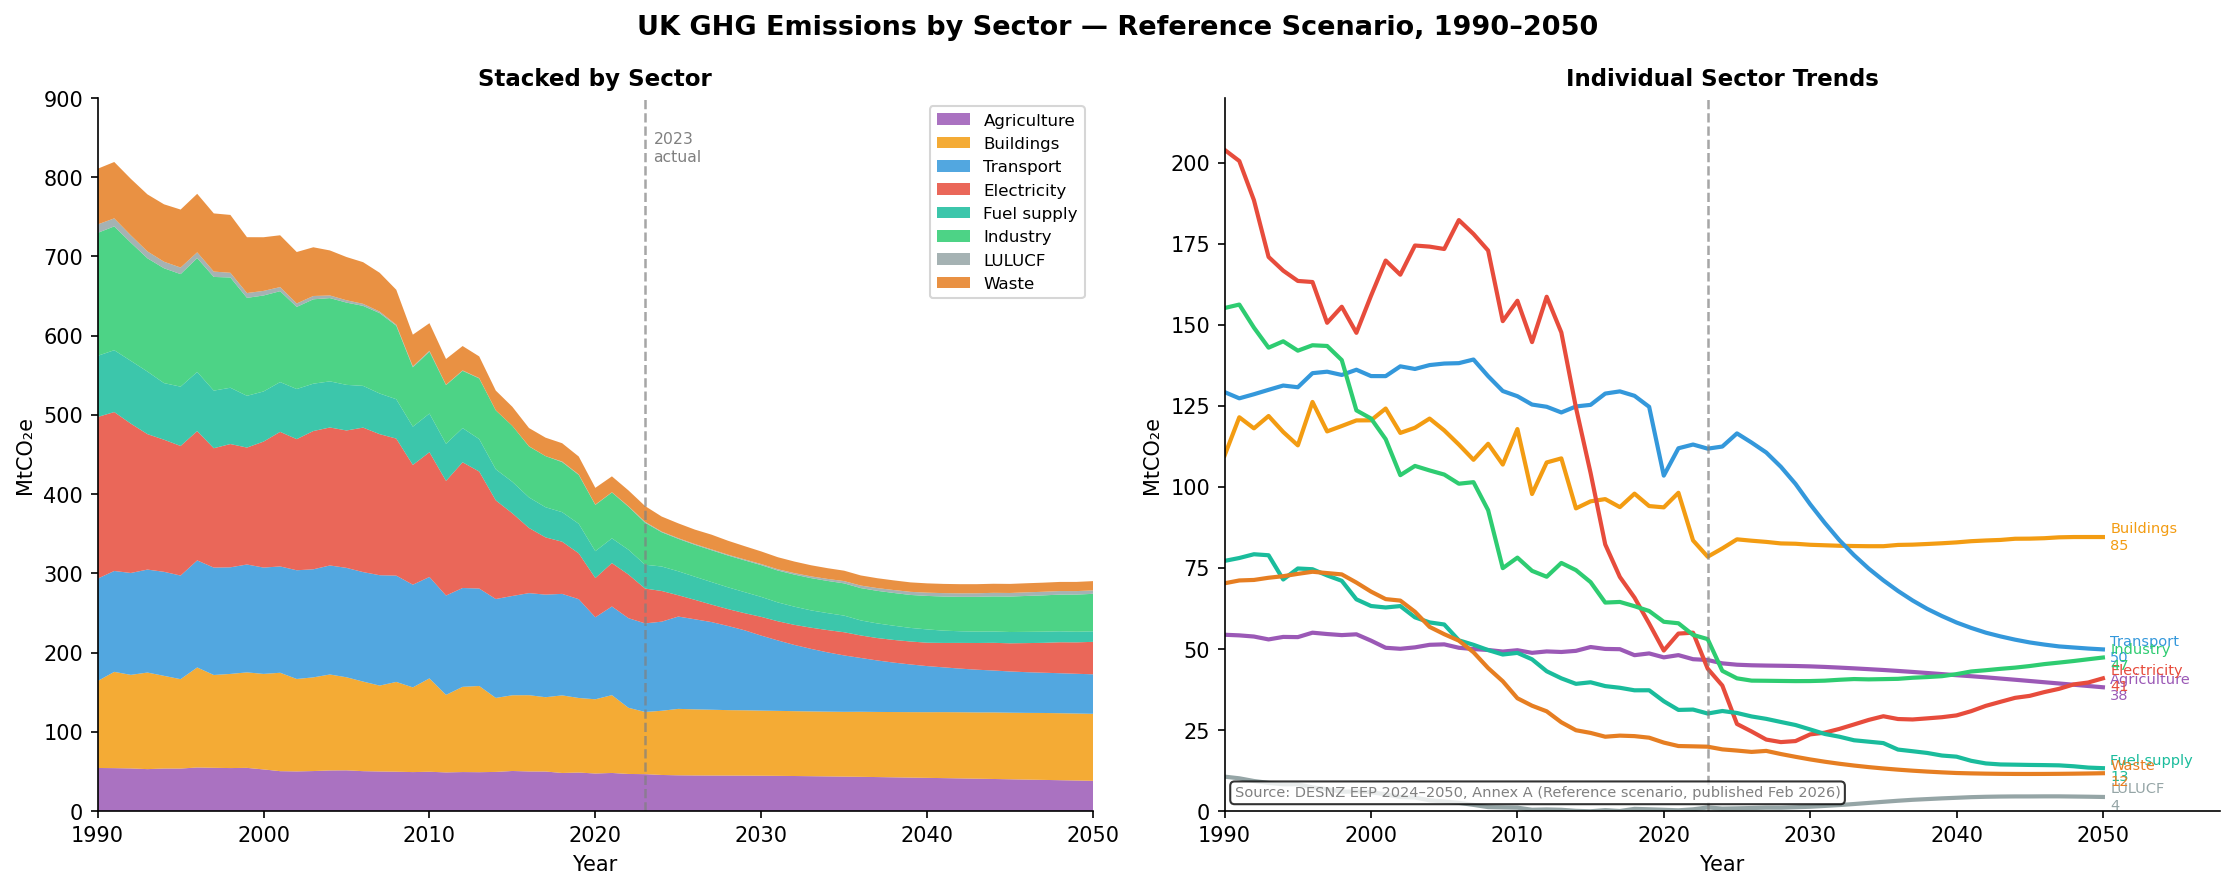

✅ Fig A saved: annex_figA_sector_proj.png


In [16]:
# ── Cell 3: 图A — Reference情景各部门投影到2050（堆叠面积）──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_years = list(range(1990, 2051))

# 左图：堆叠面积
ax1.stackplot(
    plot_years,
    [ref[s].values for s in SECTORS],
    labels=[SECTOR_SHORT[s] for s in SECTORS],
    colors=[SECTOR_COLORS[s] for s in SECTORS],
    alpha=0.85,
)
ax1.axvline(2023, color="grey", lw=1.2, ls="--", alpha=0.7)
ax1.text(2023.5, 820, "2023\nactual", fontsize=7.5, color="grey")
ax1.set_xlim(1990, 2050)
ax1.set_ylim(0, 900)
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("MtCO₂e", fontsize=10)
ax1.set_title("Stacked by Sector", fontsize=11, fontweight="bold")
ax1.legend(loc="upper right", fontsize=8, framealpha=0.8)

# 右图：折线（各部门单独趋势）
for s in SECTORS:
    ax2.plot(plot_years, ref[s].values,
             color=SECTOR_COLORS[s], lw=2,
             label=SECTOR_SHORT[s], marker="o", markersize=0)
    # 2050年终点标注
    ax2.text(2050.5, ref.loc[2050, s],
             f"{SECTOR_SHORT[s]}\n{ref.loc[2050, s]:.0f}",
             fontsize=7, color=SECTOR_COLORS[s], va="center")

ax2.axvline(2023, color="grey", lw=1.2, ls="--", alpha=0.7)
ax2.set_xlim(1990, 2058)
ax2.set_ylim(0, 220)
ax2.set_xlabel("Year", fontsize=10)
ax2.set_ylabel("MtCO₂e", fontsize=10)
ax2.set_title("Individual Sector Trends", fontsize=11, fontweight="bold")

plt.suptitle("UK GHG Emissions by Sector — Reference Scenario, 1990–2050",
             fontsize=13, fontweight="bold")
ax2.text(0.01, 0.02,
         "Source: DESNZ EEP 2024–2050, Annex A (Reference scenario, published Feb 2026)",
         transform=ax2.transAxes, fontsize=7, color="grey",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("annex_figA_sector_proj.png", bbox_inches="tight")
plt.show()
print("✅ Fig A saved: annex_figA_sector_proj.png")


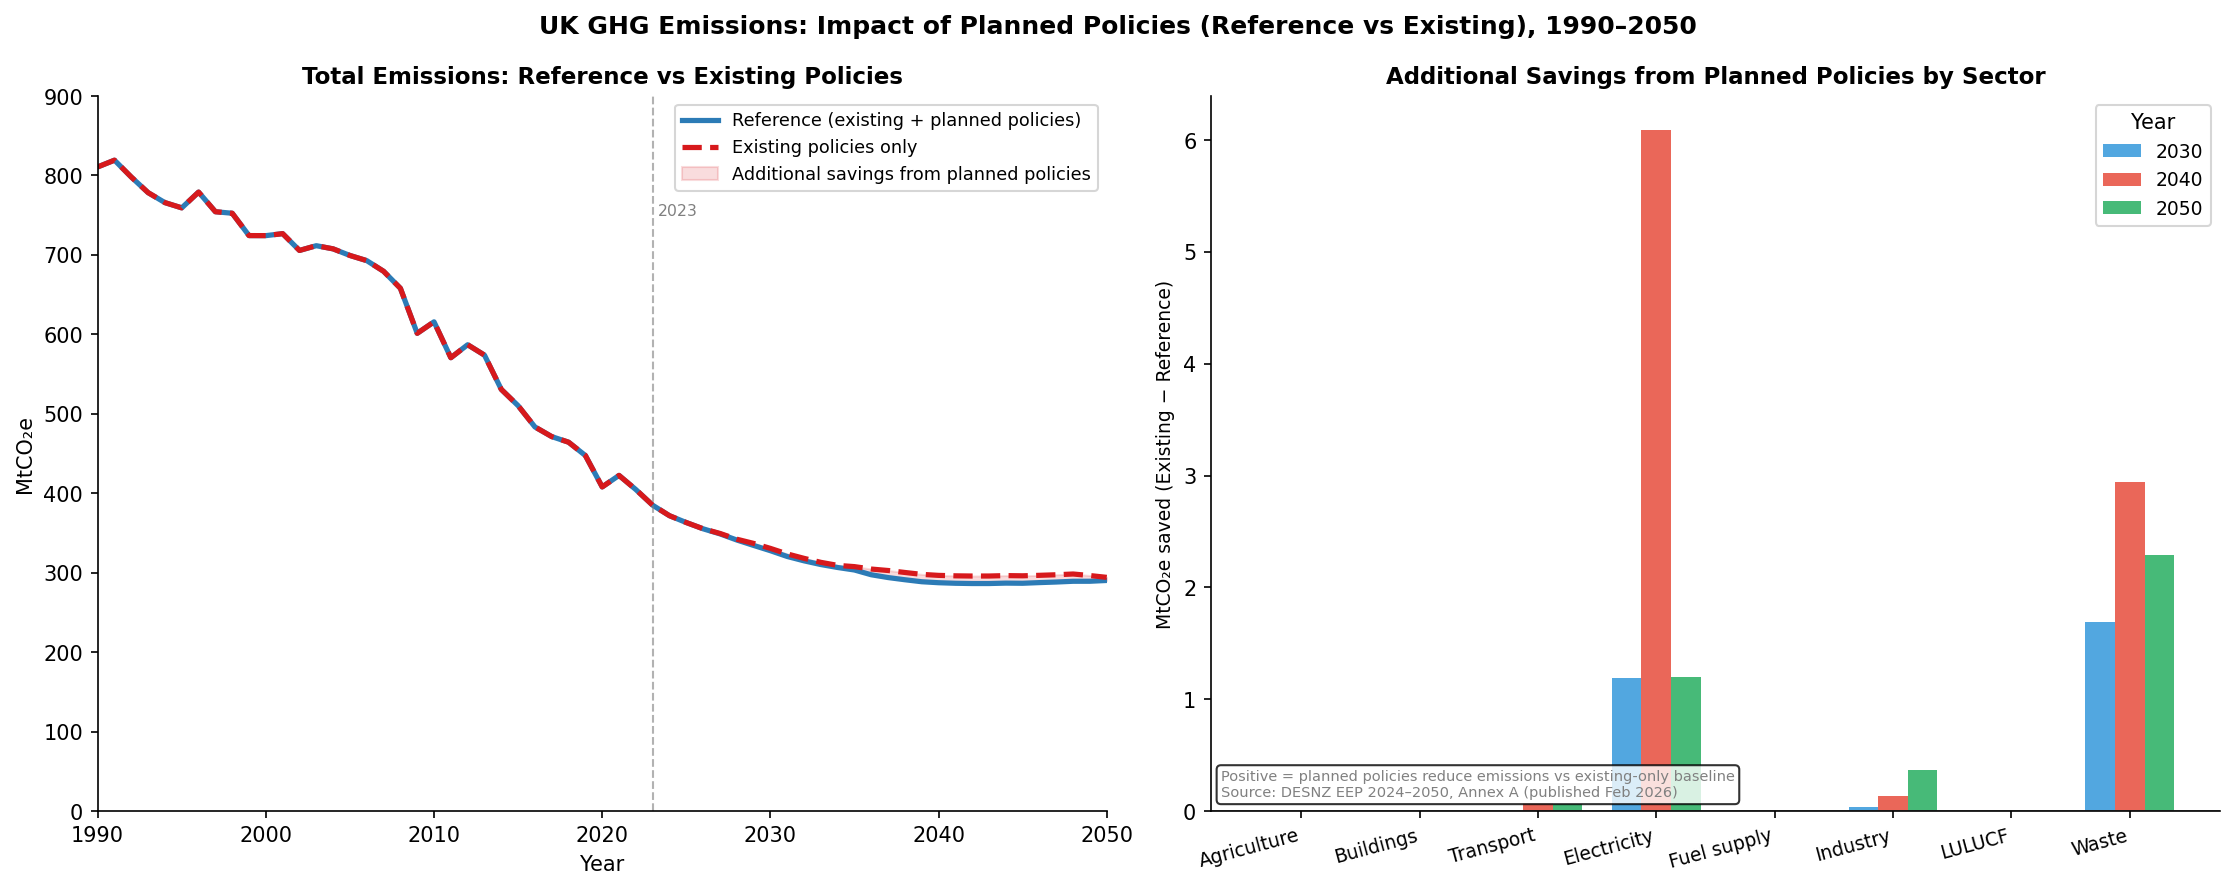

✅ Fig B saved: annex_figB_ref_vs_existing.png


In [17]:
# ── Cell 4: 图B — Reference vs Existing（计划政策额外贡献）─
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

exist = sheets["Existing"]

# 仅看投影年份 2024-2050（2023年两者相同）
proj_years = list(range(2024, 2051))

# 左图：两条总排放线 + 差值填充
ax1.plot(YEARS, ref["Total (exc. IAS)"].values,
         color="#2c7bb6", lw=2.5, label="Reference (existing + planned policies)")
ax1.plot(YEARS, exist["Total (exc. IAS)"].values,
         color="#d7191c", lw=2.5, ls="--", label="Existing policies only")

ref_vals  = ref.loc[proj_years, "Total (exc. IAS)"].values
exist_vals = exist.loc[proj_years, "Total (exc. IAS)"].values
ax1.fill_between(proj_years, ref_vals, exist_vals,
                 alpha=0.15, color="#d7191c",
                 label="Additional savings from planned policies")

ax1.axvline(2023, color="grey", lw=1, ls="--", alpha=0.6)
ax1.text(2023.3, 750, "2023", fontsize=7.5, color="grey")
ax1.set_xlim(1990, 2050)
ax1.set_ylim(0, 900)
ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("MtCO₂e", fontsize=10)
ax1.set_title("Total Emissions: Reference vs Existing Policies", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8.5, loc="upper right")

# 右图：逐部门政策节省量（Reference - Existing）at 2030, 2040, 2050
milestone_years = [2030, 2040, 2050]
sector_savings = {}
for s in SECTORS:
    sector_savings[s] = [
        exist.loc[yr, s] - ref.loc[yr, s]
        for yr in milestone_years
    ]

x = np.arange(len(SECTORS))
width = 0.25
for i, (yr, offset) in enumerate(zip(milestone_years, [-width, 0, width])):
    vals = [sector_savings[s][i] for s in SECTORS]
    ax2.bar(x + offset, vals, width,
            label=str(yr), alpha=0.85,
            color=["#3498db", "#e74c3c", "#27ae60"][i])

ax2.axhline(0, color="grey", lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels([SECTOR_SHORT[s] for s in SECTORS],
                    fontsize=9, rotation=15, ha="right")
ax2.set_ylabel("MtCO₂e saved (Existing − Reference)", fontsize=9)
ax2.set_title("Additional Savings from Planned Policies by Sector",
              fontsize=11, fontweight="bold")
ax2.legend(title="Year", fontsize=9)

ax2.text(0.01, 0.02,
         "Positive = planned policies reduce emissions vs existing-only baseline\n"
         "Source: DESNZ EEP 2024–2050, Annex A (published Feb 2026)",
         transform=ax2.transAxes, fontsize=7, color="grey",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.suptitle("UK GHG Emissions: Impact of Planned Policies (Reference vs Existing), 1990–2050",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("annex_figB_ref_vs_existing.png", bbox_inches="tight")
plt.show()
print("✅ Fig B saved: annex_figB_ref_vs_existing.png")

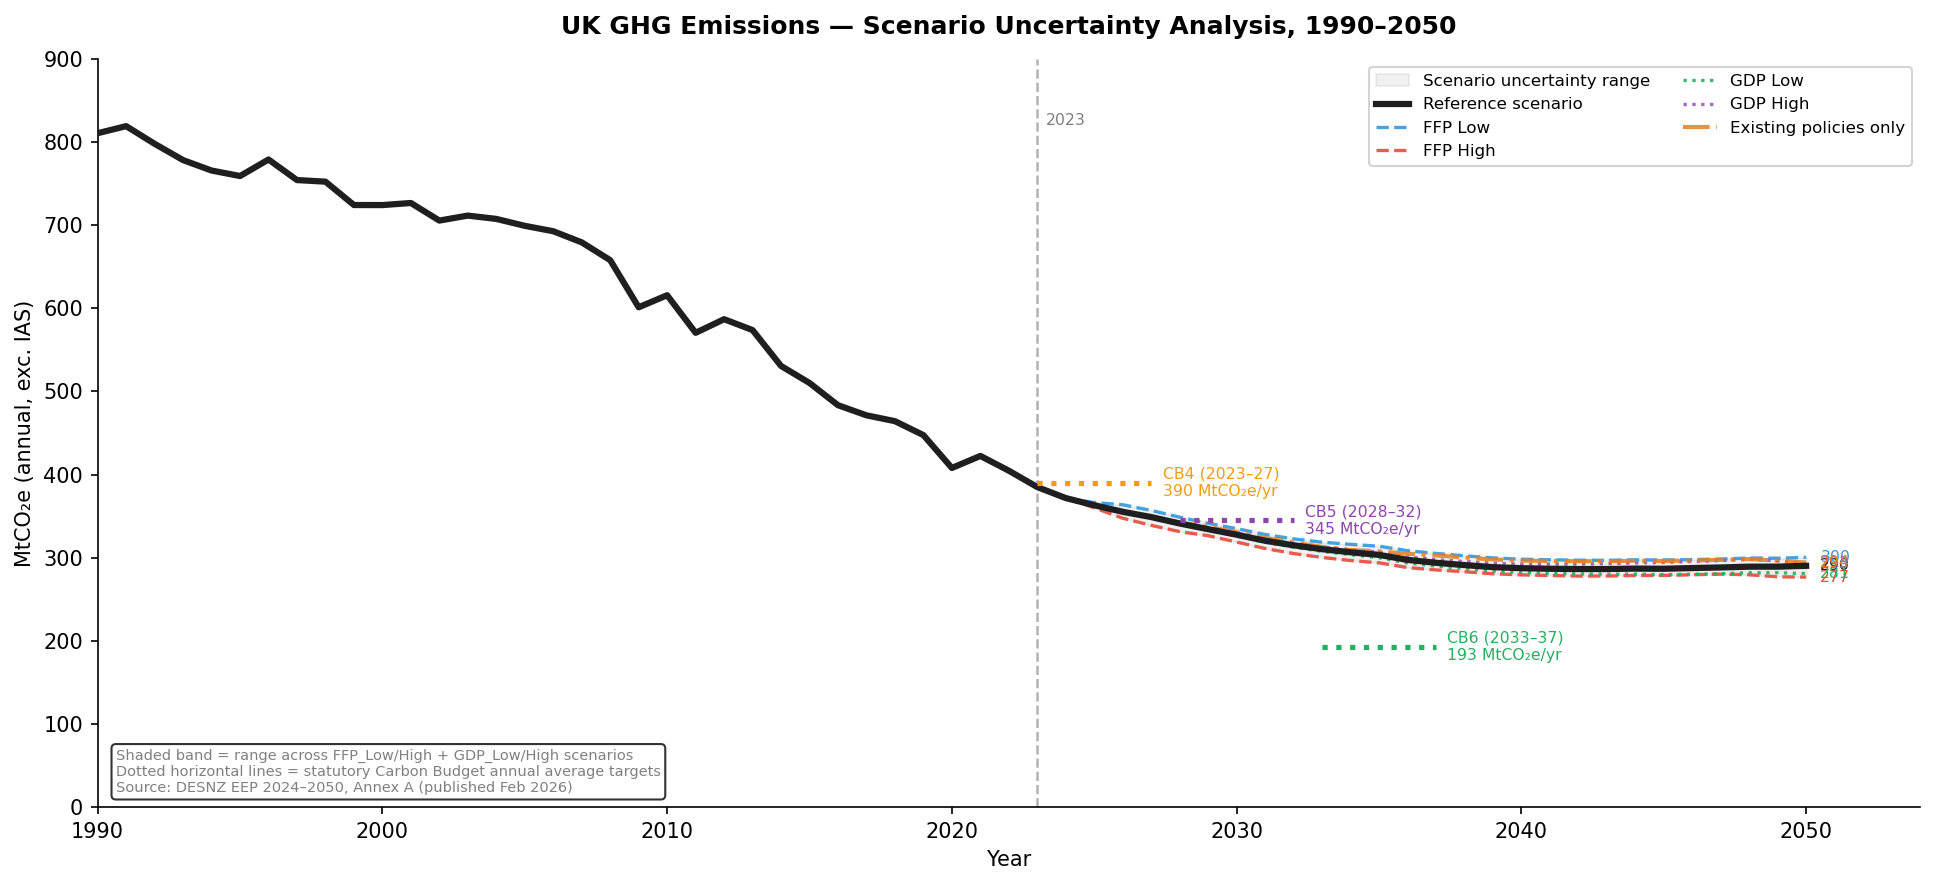

✅ Fig C saved: annex_figC_scenario_uncertainty.png


In [18]:
# ── Cell 5: 图C — 情景不确定性带（4个敏感性情景）───────────
fig, ax = plt.subplots(figsize=(13, 6))

# 四个敏感性情景总排放
sens_scenarios = ["FFP_Low", "FFP_High", "GDP_Low", "GDP_High"]
sens_labels    = ["FFP Low", "FFP High", "GDP Low", "GDP High"]
sens_colors    = ["#3498db", "#e74c3c", "#27ae60", "#9b59b6"]
sens_styles    = ["--", "--", ":", ":"]

# 画不确定性带（所有情景的min/max）
all_totals = np.array([
    sheets[sc]["Total (exc. IAS)"].values for sc in sens_scenarios
])
band_min = all_totals.min(axis=0)
band_max = all_totals.max(axis=0)

ax.fill_between(YEARS, band_min, band_max,
                alpha=0.12, color="#888888",
                label="Scenario uncertainty range")

# Reference 粗线居中
ax.plot(YEARS, ref["Total (exc. IAS)"].values,
        color="#1f1f1f", lw=3, label="Reference scenario", zorder=5)

# 各敏感性情景细线
for sc, lbl, col, ls in zip(sens_scenarios, sens_labels, sens_colors, sens_styles):
    ax.plot(YEARS, sheets[sc]["Total (exc. IAS)"].values,
            color=col, lw=1.6, ls=ls, label=lbl, alpha=0.9)

# Existing 对比
ax.plot(YEARS, exist["Total (exc. IAS)"].values,
        color="#e67e22", lw=2, ls="-.", label="Existing policies only", alpha=0.85)

# CB目标线
cb_targets_annual = {"CB4 (2023–27)": 1950/5, "CB5 (2028–32)": 1725/5, "CB6 (2033–37)": 965/5}
cb_ranges = [(2023, 2027), (2028, 2032), (2033, 2037)]
cb_colors = ["#f39c12", "#8e44ad", "#27ae60"]
for (y0, y1), (lbl, tgt), col in zip(cb_ranges, cb_targets_annual.items(), cb_colors):
    ax.hlines(tgt, y0, y1, colors=col, lw=2.5, ls=":", zorder=6)
    ax.text(y1 + 0.4, tgt, f"{lbl}\n{tgt:.0f} MtCO₂e/yr",
            fontsize=7.5, color=col, va="center")

ax.axvline(2023, color="grey", lw=1.2, ls="--", alpha=0.6)
ax.text(2023.3, 820, "2023", fontsize=7.5, color="grey")

# 2050年数值标注
for sc, col in zip(["Reference"] + sens_scenarios + ["Existing"],
                   ["#1f1f1f"] + sens_colors + ["#e67e22"]):
    val = sheets[sc].loc[2050, "Total (exc. IAS)"]
    ax.text(2050.5, val, f"{val:.0f}", fontsize=7.5, color=col, va="center")

ax.set_xlim(1990, 2054)
ax.set_ylim(0, 900)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("MtCO₂e (annual, exc. IAS)", fontsize=10)
ax.set_title("UK GHG Emissions — Scenario Uncertainty Analysis, 1990–2050",
             fontsize=12, fontweight="bold", pad=12)
ax.legend(fontsize=8, loc="upper right", framealpha=0.85, ncol=2)

ax.text(0.01, 0.02,
        "Shaded band = range across FFP_Low/High + GDP_Low/High scenarios\n"
        "Dotted horizontal lines = statutory Carbon Budget annual average targets\n"
        "Source: DESNZ EEP 2024–2050, Annex A (published Feb 2026)",
        transform=ax.transAxes, fontsize=7, color="grey",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("annex_figC_scenario_uncertainty.png", bbox_inches="tight")
plt.show()
print("✅ Fig C saved: annex_figC_scenario_uncertainty.png")


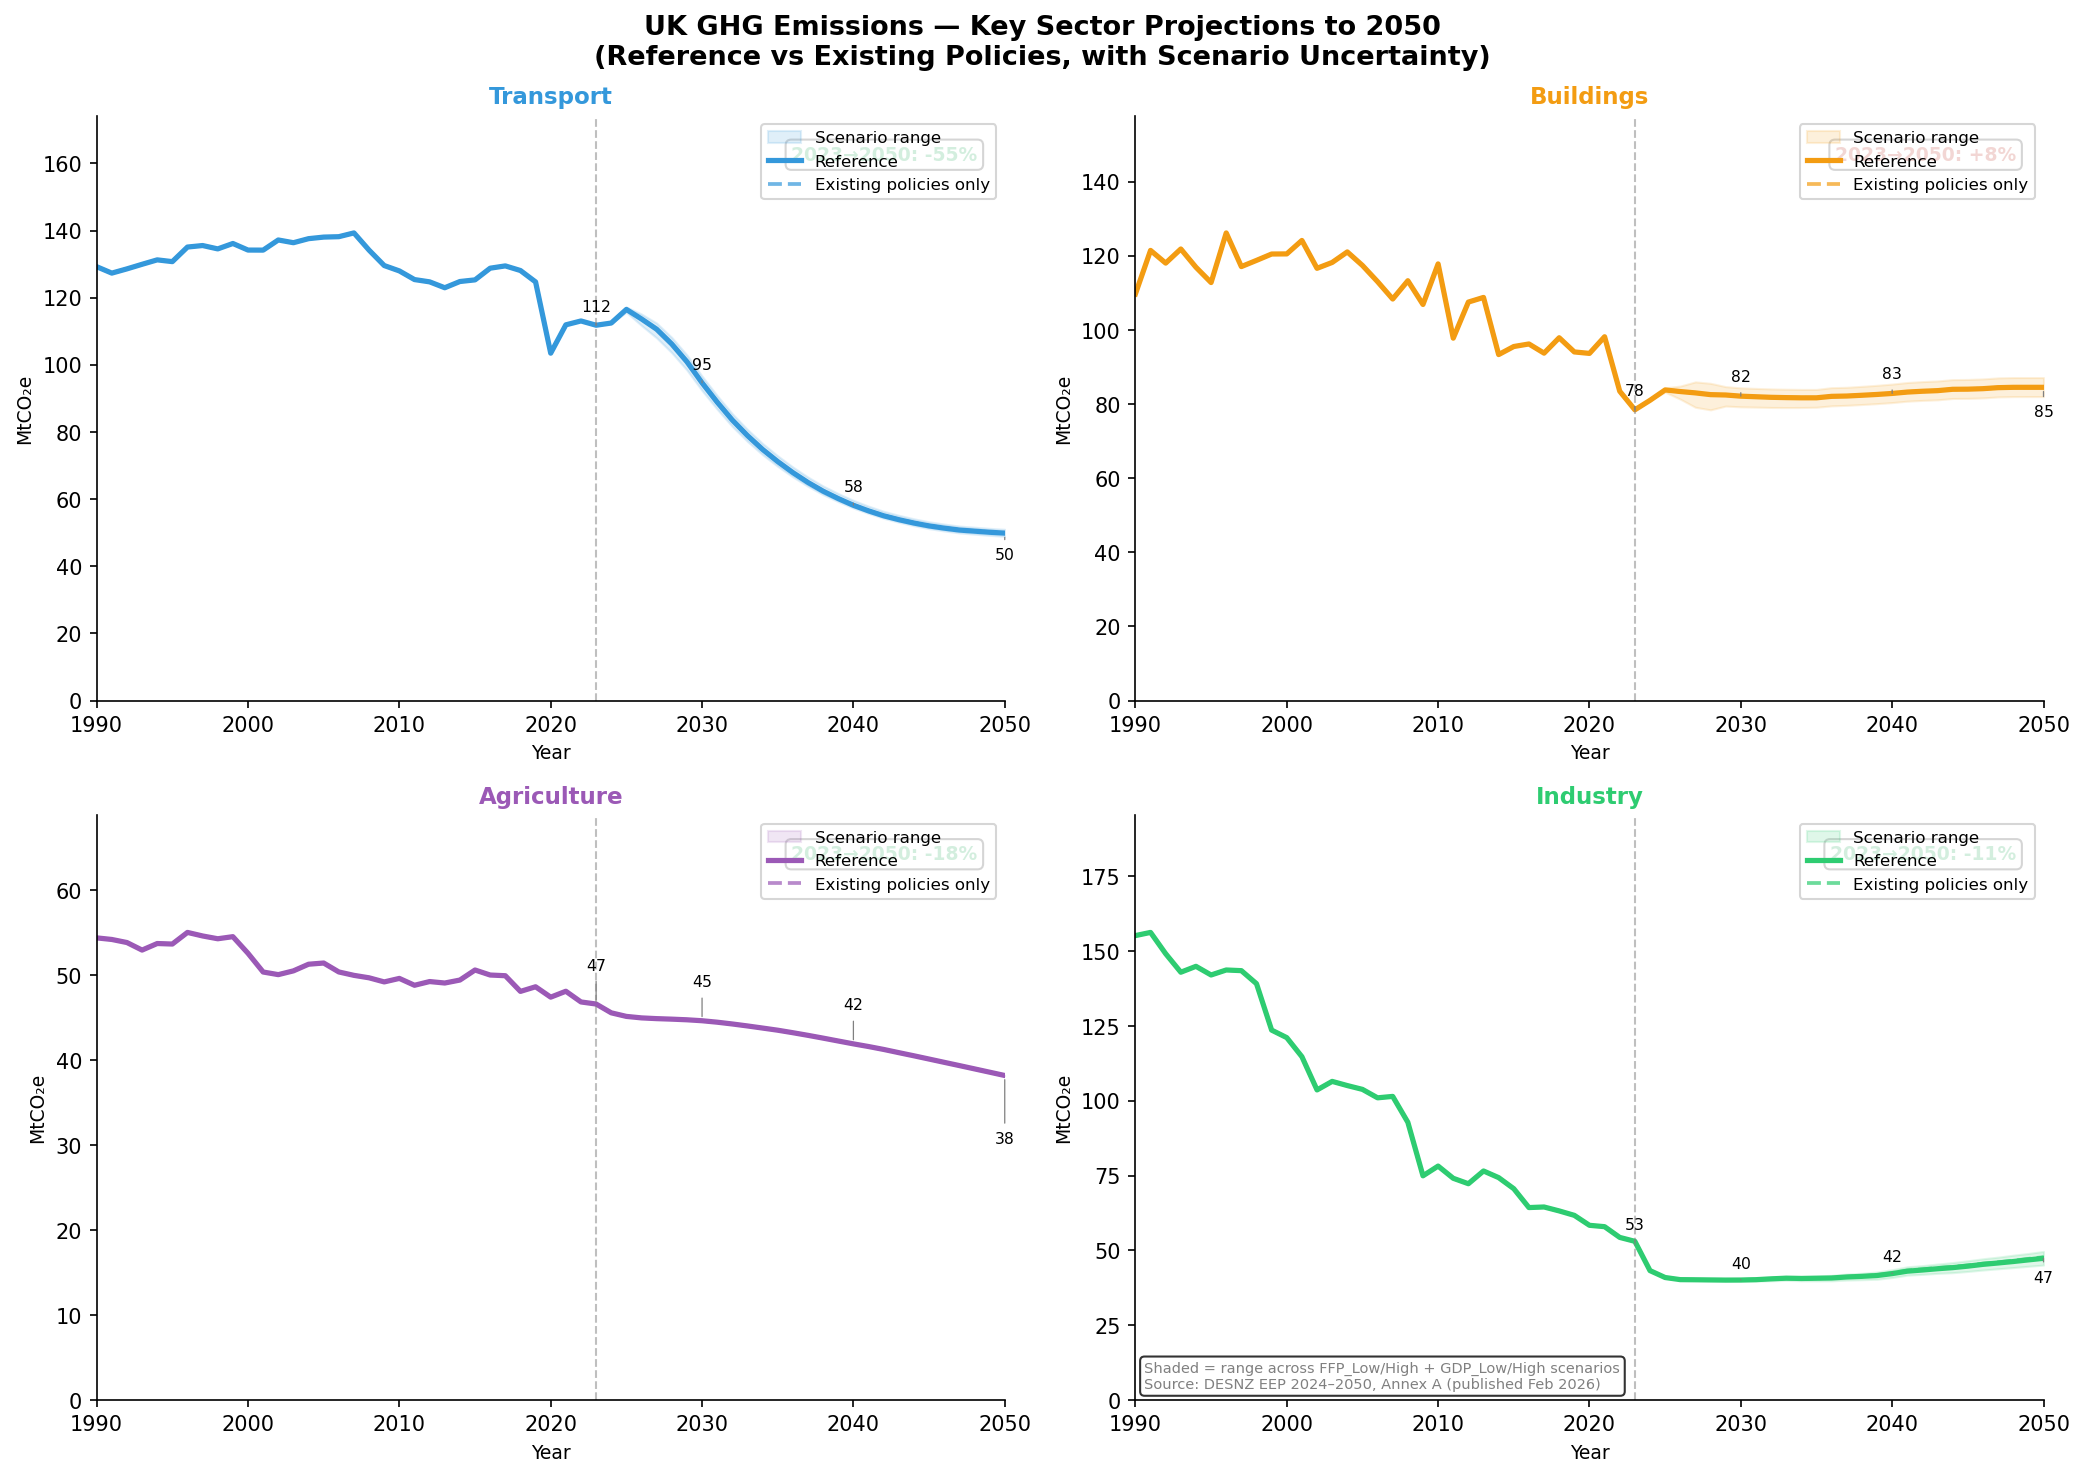

✅ Fig D saved: annex_figD_sector_deep_dive.png


In [19]:
# ── Cell 6: 图D — 减排困难部门深度分析（Transport & Buildings）
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

focus_sectors = [
    ("Domestic Transport",        "#3498db"),
    ("Buildings and product uses","#f39c12"),
    ("Agriculture",               "#9b59b6"),
    ("Industry",                  "#2ecc71"),
]

for ax, (sector, color) in zip(axes, focus_sectors):
    short = SECTOR_SHORT[sector]

    # Reference + 不确定性带
    all_sc_vals = np.array([
        sheets[sc][sector].values for sc in sens_scenarios
    ])
    band_lo = all_sc_vals.min(axis=0)
    band_hi = all_sc_vals.max(axis=0)

    ax.fill_between(YEARS, band_lo, band_hi,
                    alpha=0.15, color=color, label="Scenario range")
    ax.plot(YEARS, ref[sector].values,
            color=color, lw=2.5, label="Reference")
    ax.plot(YEARS, exist[sector].values,
            color=color, lw=1.8, ls="--", alpha=0.7, label="Existing policies only")

    # 关键年份数值
    for yr in [2023, 2030, 2040, 2050]:
        val = ref.loc[yr, sector]
        ax.annotate(f"{val:.0f}", xy=(yr, val),
                    xytext=(yr, val + (4 if yr < 2050 else -8)),
                    ha="center", fontsize=7.5,
                    arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))

    # 2023-2050减排百分比
    chg = (ref.loc[2050, sector] - ref.loc[2023, sector]) / ref.loc[2023, sector] * 100
    chg_col = "#27ae60" if chg < 0 else "#c0392b"
    ax.text(0.97, 0.95, f"2023→2050: {chg:+.0f}%",
            transform=ax.transAxes, fontsize=9, ha="right", va="top",
            color=chg_col, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    ax.axvline(2023, color="grey", lw=1, ls="--", alpha=0.5)
    ax.set_xlim(1990, 2050)
    ax.set_ylim(0, max(ref[sector].max(), exist[sector].max()) * 1.25)
    ax.set_xlabel("Year", fontsize=9)
    ax.set_ylabel("MtCO₂e", fontsize=9)
    ax.set_title(f"{short}", fontsize=11, fontweight="bold", color=color)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("UK GHG Emissions — Key Sector Projections to 2050\n"
             "(Reference vs Existing Policies, with Scenario Uncertainty)",
             fontsize=13, fontweight="bold")

axes[-1].text(0.01, 0.02,
              "Shaded = range across FFP_Low/High + GDP_Low/High scenarios\n"
              "Source: DESNZ EEP 2024–2050, Annex A (published Feb 2026)",
              transform=axes[-1].transAxes, fontsize=7, color="grey",
              bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("annex_figD_sector_deep_dive.png", bbox_inches="tight")
plt.show()
print("✅ Fig D saved: annex_figD_sector_deep_dive.png")


In [20]:
# ── Cell 7: 汇总统计 ─────────────────────────────────────────
print("\n" + "="*65)
print("Annex A — Key Findings Summary")
print("="*65)

print("\n📊 Reference scenario total emissions (exc. IAS):")
for yr in [2023, 2025, 2030, 2035, 2040, 2050]:
    val = ref.loc[yr, "Total (exc. IAS)"]
    chg = (val - ref.loc[2023, "Total (exc. IAS)"]) / ref.loc[2023, "Total (exc. IAS)"] * 100
    print(f"   {yr}: {val:6.1f} MtCO₂e  ({chg:+.1f}% vs 2023)")

print("\n📊 Sector emissions 2023 → 2050 (Reference):")
for s in SECTORS:
    v23 = ref.loc[2023, s]
    v50 = ref.loc[2050, s]
    chg = (v50 - v23) / v23 * 100
    print(f"   {SECTOR_SHORT[s]:<15}: {v23:5.1f} → {v50:5.1f} MtCO₂e  ({chg:+.0f}%)")

print("\n📊 Planned policy savings (Reference vs Existing) at 2050:")
for s in SECTORS:
    saving = exist.loc[2050, s] - ref.loc[2050, s]
    print(f"   {SECTOR_SHORT[s]:<15}: {saving:+.1f} MtCO₂e saved")

print("\n📊 Scenario range at 2050 (total exc. IAS):")
vals_2050 = {sc: sheets[sc].loc[2050, "Total (exc. IAS)"] for sc in SCENARIOS}
print(f"   Min (FFP_High): {min(vals_2050.values()):.1f} MtCO₂e")
print(f"   Max (FFP_Low):  {max(vals_2050.values()):.1f} MtCO₂e")
print(f"   Range:          {max(vals_2050.values()) - min(vals_2050.values()):.1f} MtCO₂e")
for sc, val in vals_2050.items():
    print(f"   {sc:<12}: {val:.1f}")



Annex A — Key Findings Summary

📊 Reference scenario total emissions (exc. IAS):
   2023:  385.0 MtCO₂e  (+0.0% vs 2023)
   2025:  363.2 MtCO₂e  (-5.7% vs 2023)
   2030:  327.7 MtCO₂e  (-14.9% vs 2023)
   2035:  303.4 MtCO₂e  (-21.2% vs 2023)
   2040:  287.4 MtCO₂e  (-25.3% vs 2023)
   2050:  290.2 MtCO₂e  (-24.6% vs 2023)

📊 Sector emissions 2023 → 2050 (Reference):
   Agriculture    :  46.6 →  38.2 MtCO₂e  (-18%)
   Buildings      :  78.5 →  84.6 MtCO₂e  (+8%)
   Transport      : 111.8 →  49.9 MtCO₂e  (-55%)
   Electricity    :  43.9 →  41.0 MtCO₂e  (-7%)
   Fuel supply    :  30.1 →  13.2 MtCO₂e  (-56%)
   Industry       :  53.1 →  47.4 MtCO₂e  (-11%)
   LULUCF         :   1.1 →   4.4 MtCO₂e  (+289%)
   Waste          :  19.9 →  11.7 MtCO₂e  (-41%)

📊 Planned policy savings (Reference vs Existing) at 2050:
   Agriculture    : +0.0 MtCO₂e saved
   Buildings      : +0.0 MtCO₂e saved
   Transport      : +0.1 MtCO₂e saved
   Electricity    : +1.2 MtCO₂e saved
   Fuel supply    : +0.0 Mt

In [21]:
df_raw = pd.read_excel(ANNEX_PATH, sheet_name="Reference", header=None, engine="odf")

pd.set_option("display.max_rows", 30)
pd.set_option("display.max_columns", 10)

display(df_raw.iloc[0:25, 0:8])

,0,1,2,3,4,5,6,7
0,Reference - Annex A (TES sectors) - Greenhouse...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,This worksheet contains one table. Some cells ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GHG,coverage,units,note,1990.000000,1991.000000,1992.000000,1993.000000
3,GHG (All),Total emissions (exc. IAS),MtCO2e,[note 8],810.709255,819.232836,797.975417,778.360752
4,GHG (All),Total emissions (inc. IAS),MtCO2e,[note 9],834.356590,842.456648,823.042893,804.435460
5,GHG (All),Net Carbon Account Applied,MtCO2e,[note 7],NaN,NaN,NaN,NaN
6,GHG (All),Net Carbon Account territorial (exc. IAS),MtCO2e,[note 11],NaN,NaN,NaN,NaN
7,GHG (All),Net Carbon Account territorial (inc. IAS),MtCO2e,[note 12],NaN,NaN,NaN,NaN
8,GHG (All),Agriculture,MtCO2e,NaN,54.398582,54.210997,53.850146,52.961588
9,GHG (All),Buildings and product uses,MtCO2e,NaN,109.753400,121.501395,118.077722,121.889243
